In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from cheb_ar import ChebAr
from cheb_ar.io import load_json, to_jsonable
from cheb_ar.models.ats import KAPPA_B, build_ats_hamiltonian_interaction
import numpy as np

kappa_b = KAPPA_B
n_a, n_b = 30, 11
warm_start_file = None
cheb_degree = 6
m_arnoldi_0 = 60
m_arnoldi = 120
margin_0 = 1e-2
eps_p = .1
alpha_sq_list = np.linspace(3,10,8)

def run_for_alphasq(alpha_sq, x0=None):
    """Run the full pipeline for one value of ``alpha_sq``."""
    (
        H_I, jump_ops_I, jump_ops_LdL_I, output_phase, V, T_block, params,
    ) = build_ats_hamiltonian_interaction(
        n_a=n_a, n_b=n_b, alpha_sq=alpha_sq,
        kappa_b=kappa_b, epsilon_p=eps_p,
    )

    solver = ChebAr(
        H_I, jump_ops_I, T_block,
        jump_ops_LdL=jump_ops_LdL_I, output_phase=output_phase,
        dims=(n_a, n_b), cheb_degree=cheb_degree,
    )


    if x0 is None:
        x0 = solver.make_x0(seed=0)
    min_margin = 1e-5
    m_schedule = [
        m_arnoldi_0,
        int(round(m_arnoldi_0 * np.sqrt(2))),
        2 * m_arnoldi_0,
    ]
    m_arnoldi_0_used = None
    margin_used = None
    ritz_vals = None
    last_exc = None
    margin = margin_0
    for m0 in m_schedule:
        try:
            _, _, ritz_vals = solver.first_estimation(x0, m_arnoldi=m0)
            solver.setup_chebyshev(ritz_vals, margin=margin)
            m_arnoldi_0_used, margin_used = m0, margin
            break
        except Exception as exc:
            last_exc = exc
            print(
                f"setup_chebyshev failed "
                f"(m_arnoldi_0={m0}, margin={margin:.3e}): {exc}"
            )
    if margin_used is None:
        if ritz_vals is None:
            raise last_exc  # even the first estimation itself failed
        margin = margin / 2
        while margin >= min_margin:
            try:
                solver.setup_chebyshev(ritz_vals, margin=margin)
                m_arnoldi_0_used, margin_used = m_schedule[-1], margin
                break
            except Exception as exc:
                last_exc = exc
                print(
                    f"setup_chebyshev failed "
                    f"(m_arnoldi_0={m_schedule[-1]}, margin={margin:.3e}): {exc}"
                )
                margin /= 2
        if margin_used is None:
            raise last_exc

    
    Q, H, mu_list = solver.arnoldi_hessenberg(
        x0, solver.chebyshev_filter, m_arnoldi
    )

    rate_bf = solver.rate_from_mu(mu_list[-1])
    x_ritz, _ = solver.ritz_vector(Q, H, m_arnoldi, target=mu_list[-1])
    res = solver.residual_check(x_ritz)

    return {
        "alpha_sq": alpha_sq,
        "eps_p": eps_p,
        "kappa_b": kappa_b,
        "n_a": n_a,
        "n_b": n_b,
        "cheb_degree": cheb_degree,
        "m_arnoldi_0": m_arnoldi_0,
        "m_arnoldi": m_arnoldi,
        "rate_bf": to_jsonable(rate_bf),
        "x_ritz": to_jsonable(x_ritz),
        "res": to_jsonable(res),
        "params": to_jsonable(params),
    }

x_ritz_warm = None
if warm_start_file is not None:
    warm_data = load_json(warm_start_file)
    x_ritz_warm = [d.get("x_ritz") for d in warm_data]

results = []
for i, alpha_sq in enumerate(alpha_sq_list):
    x0 = None
    if x_ritz_warm is not None and i < len(x_ritz_warm):
        x0 = x_ritz_warm[i]
    try:
        result = run_for_alphasq(alpha_sq, x0)
    except Exception as exc:
        print(f"alpha_sq = {alpha_sq} FAILED: {exc}")
        results.append({
            "alpha_sq": float(alpha_sq),
            "eps_p": eps_p,
            "kappa_b": kappa_b,
            "n_a": n_a,
            "n_b": n_b,
            "cheb_degree": cheb_degree,
            "m_arnoldi_0": m_arnoldi_0,
            "m_arnoldi": m_arnoldi,
            "error": f"{type(exc).__name__}: {exc}",
        })
        continue

    print(f"alpha_sq = {alpha_sq}")
    print(f"rate_bf  = {result['rate_bf']}")
    print(f"res_rel  = {result['res']['res_rel']}")
    results.append(result)

/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIADataArray` has been converted to a `DenseDataArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/dynamiqs/qarrays/dataarray.py:214: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  return self.__add__(y)
/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/dynamiqs/qarrays/qarray.py:534: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  result = self.data + y.data
|██████████| 100.0% ◆ elapsed 92.14ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 81.20ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 73.02ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 73.10ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 

setup_chebyshev failed (m_arnoldi_0=60, margin=1.000e-02): find_enclosing_ellipse failed to find a valid ellipse (center_a=inf, semi_re=inf, semi_im=inf). No ellipse through the vertex encloses all Ritz values with margin=0.01; try a smaller margin or a different num_a.


|██████████| 100.0% ◆ elapsed 74.85ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 74.15ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 72.60ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 72.98ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 70.67ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 70.91ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 70.81ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 70.96ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 70.90ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 70.90ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 70.89ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 72.76ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 72.80ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 72.60ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 70.75ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 70.92ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 71.34ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 7

alpha_sq = 8
rate_bf  = {'real': 6.861681518248589e-07, 'imag': -1.1454885195313632e-16}
res_rel  = 1.9248187282149152e-05


/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIADataArray` has been converted to a `DenseDataArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/dynamiqs/qarrays/dataarray.py:214: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  return self.__add__(y)
/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/dynamiqs/qarrays/qarray.py:534: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  result = self.data + y.data
|██████████| 100.0% ◆ elapsed 95.79ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 92.70ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 78.74ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 71.70ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 

...

alpha_sq = 9
rate_bf  = {'real': 2.0467512199673367e-07, 'imag': 6.080405503335119e-16}
res_rel  = 1.2387506729791811e-05


/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/dynamiqs/qarrays/dataarray.py:214: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  return self.__add__(y)
/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/dynamiqs/qarrays/qarray.py:534: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  result = self.data + y.data
|██████████| 100.0% ◆ elapsed 96.69ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 86.57ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 85.89ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 77.03ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 73.65ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 73.41ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 73.82ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 73.48ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 73.68ms ◆ remaining 0.00ms
|██████

setup_chebyshev failed (m_arnoldi_0=60, margin=1.000e-02): find_enclosing_ellipse failed to find a valid ellipse (center_a=inf, semi_re=inf, semi_im=inf). No ellipse through the vertex encloses all Ritz values with margin=0.01; try a smaller margin or a different num_a.


|██████████| 100.0% ◆ elapsed 79.01ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 76.82ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 76.77ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 73.82ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 73.64ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 74.24ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 74.22ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 74.00ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 74.09ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 73.92ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 74.18ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 74.04ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 73.76ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 74.14ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 74.13ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 74.16ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 74.66ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 7

alpha_sq = 10
rate_bf  = {'real': 1.0609920424988148e-07, 'imag': -2.7661760356927003e-17}
res_rel  = 2.865520717355415e-06


In [14]:
bf_list_dict = [{'real': 0.0002680569478591351, 'imag': 0.0007391258445025774}, 
           {'real': 0.0003161293099639619, 'imag': 0.0002275267601220811}, 
           {'real': 5.0324538518722224e-05, 'imag': -8.430310061907255e-16},
            {'real': 9.907911406377715e-06, 'imag': 3.430652362639189e-16},
            {'real': 2.401054205767288e-06, 'imag': 2.9725202785555206e-16},
            {'real': 6.861681518248589e-07, 'imag': -1.1454885195313632e-16},
            {'real': 2.0467512199673367e-07, 'imag': 6.080405503335119e-16},
            {'real': 1.0609920424988148e-07, 'imag': -2.7661760356927003e-17}]
bf_list = np.array([bf["real"]+1j*bf["imag"] for bf in bf_list_dict])

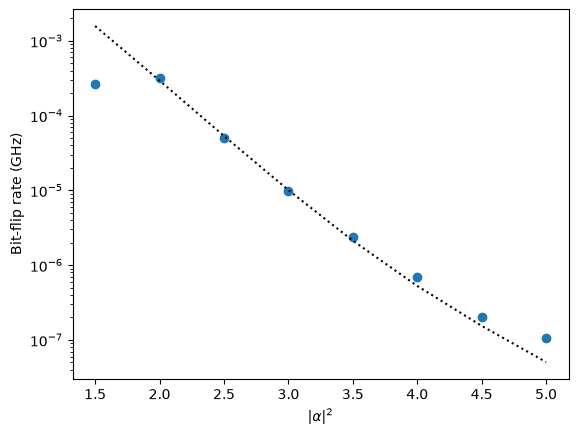

In [30]:
import matplotlib.pyplot as plt
from cheb_ar.models.ats import E_J, PHI_A, PHI_B
g = np.sin(eps_p) * E_J * PHI_A**2 * PHI_B
kappa_2 = 4 * g**2 / kappa_b
kappa_1 = 0.005 * kappa_2
pert_th = kappa_1*(alpha_sq_list/2)*np.exp(-4*alpha_sq_list/2)+kappa_1**2/(2*kappa_2)*np.exp(-2*alpha_sq_list/2)
plt.scatter(alpha_sq_list/2, bf_list.real)
plt.plot(alpha_sq_list/2, pert_th*3000, ls=":", c='k')
plt.yscale("log")
plt.ylabel("Bit-flip rate (GHz)")
plt.xlabel(r"$|\alpha|^2$")
plt.show()